# Information Bottleneck Analysis

lets investigate the **compressibility of the semantic dimension**. 
By forcing the latent space through an artificial PCA bottleneck, we measure how much semantic information survives. We prove that the Channel-Aware Model (M2) distributes its information across a much wider space, sacrificing compressibility to achieve **Latent Semantic Diversity** against channel noise.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import T5Tokenizer
import warnings
warnings.filterwarnings('ignore')

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.llm_model import GenerativeSemanticModel
from src.llm_model_2 import AdvancedGenerativeSemanticModel

sns.set_theme(style="whitegrid", palette="muted")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = T5Tokenizer.from_pretrained("t5-small", local_files_only=True)

data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=1000)
loader.scan_and_load()
sentences = loader.all_sentences[:300]  

model1 = GenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model1_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic.pt")
if os.path.exists(model1_path): model1.load_state_dict(torch.load(model1_path, map_location=device, weights_only=True))
model1.eval()

model2 = AdvancedGenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model2_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic_advanced.pt")
if os.path.exists(model2_path): model2.load_state_dict(torch.load(model2_path, map_location=device, weights_only=True))
model2.eval()

m1_raw = []
m2_raw = []

with torch.no_grad():
    for sent in sentences:
        inputs = tokenizer(sent, return_tensors="pt", max_length=20, padding="max_length", truncation=True).to(device)
        
        h1 = model1.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], return_dict=True).last_hidden_state.squeeze(0)
        
        h2_pristine = model2.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], return_dict=True).last_hidden_state.squeeze(0)
        snr_tensor = model2._get_snr_tensor(1, device, 20.0) # Extract cleanly adapted states
        h2 = h2_pristine + model2.snr_embed(snr_tensor).squeeze(0)
        
        m1_raw.append(h1)
        m2_raw.append(h2)

#512 size ka k
H1 = torch.cat(m1_raw, dim=0)
H2 = torch.cat(m2_raw, dim=0)

# Center the manifolds for PCA
H1_c = H1 - H1.mean(dim=0)
H2_c = H2 - H2.mean(dim=0)

print(f"Extracted Shape: {H1_c.shape}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Extracted Shape: torch.Size([6000, 512])


###Spectral Decay (SVD)
lets calculate the precise Singular Value Decomposition (SVD) of both models. A sharp decay implies the information is compressed into very few dimensions. A flat implies the semantic information is heavily distributed

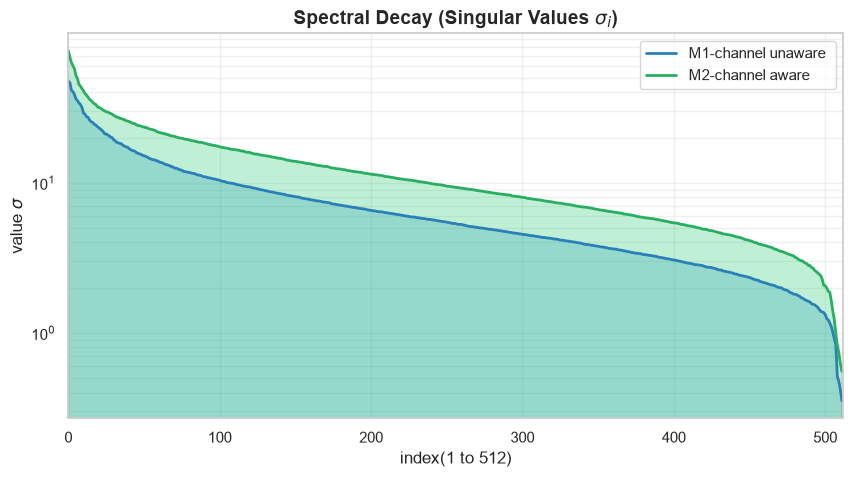

M2 maintains significantly more variance in deep dimensions


In [4]:
# SVD: H = USV^T
_, S1, _ = torch.svd(H1_c)
_, S2, _ = torch.svd(H2_c)

sigma1 = S1.cpu().numpy()
sigma2 = S2.cpu().numpy()

plt.figure(figsize=(10, 5))
plt.fill_between(range(len(sigma1)), sigma1, color="#3498db", alpha=0.3)
plt.fill_between(range(len(sigma2)), sigma2, color="#2ecc71", alpha=0.3)
plt.plot(sigma1, label="M1-channel unaware ", color="#2980b9", lw=2)
plt.plot(sigma2, label="M2-channel aware ", color="#27ae60", lw=2)
plt.title("Spectral Decay (Singular Values $\sigma_i$)", fontsize=14, fontweight='bold')
plt.xlabel("index(1 to 512)", fontsize=12)
plt.ylabel("value $\sigma$", fontsize=12)
plt.xlim(0, 512)
plt.yscale('log') 
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

print("M2 maintains significantly more variance in deep dimensions")

### 2. Information Bottleneck Reconstruction Error
If we bottleneck the vectors to exactly $k$ dimensions, the loss Mathematically according to the Frobenius norm is exactly the sum of squares of the discarded singular values:

$L(k) = \frac{1}{N \cdot d} \sum_{i=k+1}^{512} \sigma_i^2$

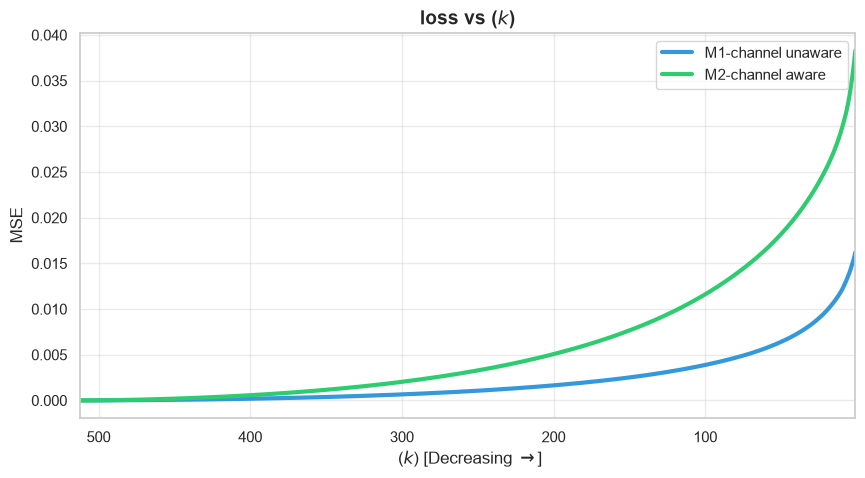

In [8]:
N, d = H1_c.shape
eigenvalues1 = sigma1 ** 2
eigenvalues2 = sigma2 ** 2

k_values = np.arange(1, 513)
mse1 = []
mse2 = []

for k in k_values:
    if k == 512:
        loss1, loss2 = 0.0, 0.0
    else:
        loss1 = np.sum(eigenvalues1[k:]) / (N * d)
        loss2 = np.sum(eigenvalues2[k:]) / (N * d)
    mse1.append(loss1)
    mse2.append(loss2)

plt.figure(figsize=(10, 5))


plt.plot(k_values, mse1, lw=3, color='#3498db', label='M1-channel unaware')
plt.plot(k_values, mse2, lw=3, color='#2ecc71', label='M2-channel aware')

plt.gca().invert_xaxis() 

plt.title("loss vs ($k$)", fontsize=14, fontweight='bold')
plt.xlabel(r" ($k$) [Decreasing $\rightarrow$]", fontsize=12)
plt.ylabel("MSE", fontsize=12)
plt.xlim(512, 1)
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

